## Snippet 1- Build and explore a frequency table with FreqTab
This snippet introduces the FreqTab class to compute an empirical frequency distribution from a small sequence. It demonstrates how to create the table, visualize it, look up frequencies (including missing values), and inspect its internal structure, following the chapter’s focus on data-driven distributions.

1.0    1
2.0    2
3.0    1
5.0    1
Name: , dtype: int64
2
2
0
qs: [1. 2. 3. 5.]
fs: [1 2 1 1]
1.0 1
2.0 2
3.0 1
5.0 1



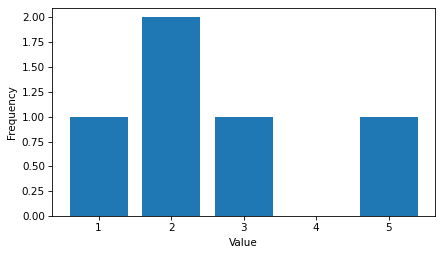

In [14]:
"""    
Frequency Tables
Context: this snippet builds a frequency table from a sequence and demonstrates lookup, visualization, and iteration
Plain-English: it counts occurrences of values, plots them, and shows how to query and inspect the distribution
Real-world: frequency tables are used to summarize discrete data such as survey responses or event counts
Reappears: yes; frequency and probability distributions are central to this chapter

"""

from thinkstats import decorate

# decorate function is used to add titles, axis labels, and other styling to plots
# Decorate the current axes
# generally it takes in a matplotlib plot and customizes it by adding the following arguments
# The keyword arguments of decorate are title='Title', xlabel='x', ylabel='y'

from empiricaldist import FreqTab  # import FreqTab class for building frequency tables

# "empirical” means that the distributions are based on data rather than mathematical models.
# empiricaldist provides a class called "FreqTab" that we can use to compute and plot frequency tables.
# A FreqTab is a kind of Pandas Series that contains values and their frequencies
# "from_seq" is method in FreqTab that takes a sequence and makes a Freq Tab object
# "bar" is a method in FreqTab that plots the frequency table as a bar chart
# In bar() we can use the arguments like "width", "color", label, "alpha" ; where alpha means transparency
# A previous version of "bar" function used as pd.Series.plot.bar, but that was a mistake, 
# because that function treats the quantities as categorical, even if they are numerical, leading to hilariously unexpected results!


t = [1.0, 2.0, 2.0, 3.0, 5.0]  # define a sequence of numeric values (data)

ftab = FreqTab.from_seq(t)  # create a frequency table from the sequence
print(ftab)  # display values and their frequencies


# ftab.bar() creates the plot, and decorate() modifies it by adding labels to the same figure
# decorate() modifies the current matplotlib plot using plt.gca(), so it applies to the plot created by ftab.bar()

ftab.bar()  # plot frequency table as a bar chart
decorate(xlabel="Value", ylabel="Frequency")  # label axes for readability


print(ftab[2.0])  # Series-style lookup: returns frequency for value 2.0
print(ftab(2.0))  # function-style lookup: unlike a Pandas Series, it also returns frequency for 2.0
print(ftab(4.0))  # lookup for value not present → the function syntax returns 0 instead of error


ftab.qs  # attribute from FreqTab: returns an array of unique values (quantities), qs stands for quantities
print("qs:", ftab.qs)
ftab.fs  # attribute from FreqTab: returns array of frequencies corresponding to each value, fs stands for frequencies
print("fs:", ftab.fs)


# items() lazily iterate over (index, value) tuples.
# lazy iterator generates (value, frequency) pairs one at a time, only when needed, instead of storing all at once

for x, freq in ftab.items():  # iterate through value-frequency pairs
    print(x, freq)  # print each value and its count


"""
Interpretation
ftab contains the empirical distribution of values in t.
The bar plot shows how often each value occurs.
ftab[2.0] and ftab(2.0) both return the count for 2.0, but function syntax safely returns 0 for missing values.
ftab.qs lists observed values, and ftab.fs lists their frequencies.
The loop prints each value with its frequency, useful for inspection or processing.
If unexpected values appear, it may indicate issues in the input data sequence.

"""

print()

## Snippet 2- Set up dependencies and load NSFG pregnancy data
This snippet prepares the environment by ensuring required packages and files are available, then loads the NSFG pregnancy dataset using a helper function. This follows the chapter’s workflow of setting up data sources before analyzing distributions.

In [2]:
"""" 
Data Loading
Context: this snippet installs dependencies, downloads required files, and loads the NSFG dataset for analysis
Plain-English: it ensures everything is available and reads the dataset into a DataFrame
Real-world: setup steps like installing packages and fetching data are common in reproducible data workflows
Reappears: yes; environment setup and data loading recur in most data analysis tasks

"""
# ensure statadict is available for reading data dictionary files
try:
    import statadict
except ImportError:
    %pip install statadict  # install if missing



# import one function to pull a filename from an online URL, and one to check whether that file is already present
from os.path import basename, exists  
# Define a reusable helper function that takes a single parameter: URL str(string representing the file to download)
def download(url):
    filename = basename(url)  
    # Extract the filename from the URL

    print(f" Downloaded {filename} from URL") 
    # To check whether the file already exists in the current directory
     
    if not exists(filename):
        from urllib.request import urlretrieve  
        # Import the downloader only when needed

        local, _ = urlretrieve(url, filename)  
        # fetch the file from the URL and save it locally under the chosen filename

        print("Downloaded " + local)
    # return object of urlretrieve is 2 items which are (filename, headers) where headers is metadata from the server



# download required files (helper module and dataset files)
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")  # helper module for reading NSFG data
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")  # data dictionary file
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")  # compressed dataset file

# import data-reading function
# nsfg.py is a module for the code that prof. used to load and clean the NSFG data
# read_fem_preg() function reads pregnancy data, adds many columns, modifies the DataFrame repeatedly

from nsfg import read_fem_preg  # function that loads and parses NSFG pregnancy dataset
preg = read_fem_preg()  # load dataset into DataFrame named preg


live = preg.query("outcome == 1")  # select only live birth records
print(live)

# outcome is an integer for the outcome of the pregnancy. The code 1 indicates a live birth.
# this chapter, we’ll focus on pregnancies that ended in live birth.


""""
Interpretation
This cell ensures required packages and files are available, then loads the dataset.
download() fetches necessary files if they are missing.
read_fem_preg() reads the raw data using the dictionary and returns a pandas DataFrame.
preg now contains the full NSFG pregnancy dataset ready for analysis.
If errors occur, they are usually due to missing files, failed downloads, or missing dependencies.
live contains only rows where outcome == 1, meaning live births.
This subset is commonly used for analyzing birth weights and pregnancy durations.
If live is empty, it may indicate an issue with the outcome column or earlier data loading steps.
"""

print()

 Downloaded nsfg.py from URL
Downloaded nsfg.py
 Downloaded 2002FemPreg.dct from URL
 Downloaded 2002FemPreg.dat.gz from URL
       caseid  pregordr  howpreg_n  howpreg_p  moscurrp  nowprgdk  pregend1  \
0           1         1        NaN        NaN       NaN       NaN       6.0   
1           1         2        NaN        NaN       NaN       NaN       6.0   
2           2         1        NaN        NaN       NaN       NaN       5.0   
3           2         2        NaN        NaN       NaN       NaN       6.0   
4           2         3        NaN        NaN       NaN       NaN       6.0   
...       ...       ...        ...        ...       ...       ...       ...   
13581   12568         2        NaN        NaN       NaN       NaN       5.0   
13584   12569         2        NaN        NaN       NaN       NaN       6.0   
13588   12571         1        NaN        NaN       NaN       NaN       6.0   
13591   12571         4        NaN        NaN       NaN       NaN       6.0   
13592 

/Users/saadmanchowdhury/Desktop/All Github projects/01._eda_and_regression/drafts/nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


## Snippet 3- Build and visualize frequency tables for key variables
This snippet creates frequency tables for birth weight (pounds and ounces), mother’s age, and pregnancy length using only live births. It visualizes each distribution and identifies the most common values, following the chapter’s focus on exploring empirical distributions.

birthwgt_lb
0.0        8
1.0       40
2.0       53
3.0       98
4.0      229
5.0      697
6.0     2223
7.0     3049
8.0     1889
9.0      623
10.0     132
11.0      26
12.0      10
13.0       3
14.0       3
15.0       1
Name: birthwgt_lb, dtype: int64
7.0
7.0
birthwgt_oz
0.0     1037
1.0      408
2.0      603
3.0      533
4.0      525
5.0      535
6.0      709
7.0      501
8.0      756
9.0      505
10.0     475
11.0     557
12.0     555
13.0     487
14.0     475
15.0     378
Name: birthwgt_oz, dtype: int64
agepreg
10.83    1
10.91    1
11.75    1
12.66    1
13.00    1
        ..
41.75    1
42.41    1
42.75    1
43.00    1
44.08    1
Name: agepreg, Length: 342, dtype: int64
prglngth
0        1
4        1
9        1
13       1
17       2
18       1
19       1
20       1
21       2
22       7
23       1
24      13
25       3
26      35
27       3
28      32
29      21
30     138
31      27
32     115
33      49
34      60
35     311
36     321
37     455
38     607
39    4693
40    1116
4

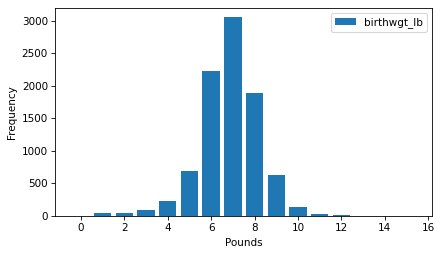

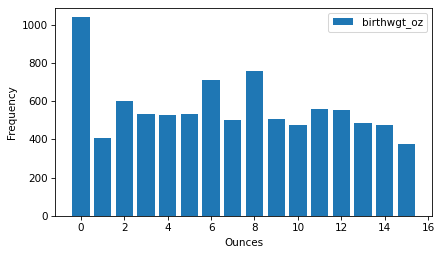

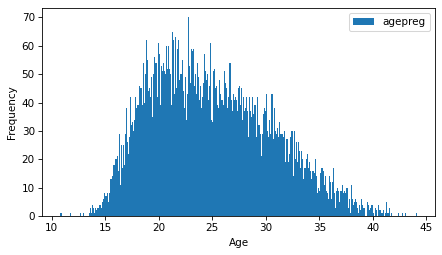

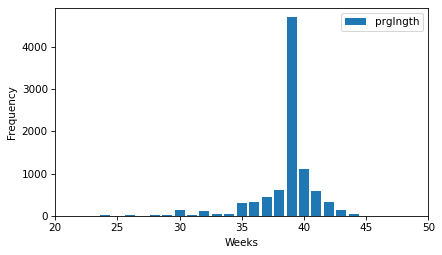

In [3]:
"""
Exploratory Data Analysis -- Visualization
Context: this snippet builds frequency tables for key variables and visualizes their distributions for live births
Plain-English: it counts values, plots distributions, and identifies the most common values in the data
Real-world: this pattern is used to explore distributions before modeling or statistical analysis
Reappears: yes; frequency tables and visualization are central to distribution analysis

"""


import matplotlib.pyplot as plt  # import pyplot so we can create a new figure for each plot

# FreqTab.from_seq to count the number of times each quantity appears in birthwgt_lb, which is the pounds part of the birth weights. 
# The name argument gives the FreqTab object a name, which is used as a label when we plot it.

ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name="birthwgt_lb")  # create frequency table for birth weight in pounds
print(ftab_lb)
plt.figure()  # start a new figure so this plot does not overlap with later ones
ftab_lb.bar()  # plot distribution of birth weight (pounds)
decorate(xlabel="Pounds", ylabel="Frequency")  # label axes


# To find the mode, we can use the method "idxmax", which finds the value associated with the highest frequency.
# FreqTab provides a method called "mode" that does the same thing.
# The mode (most frequent value) is 7.0, stored as a NumPy float in both cases.
# FreqTab is built on top of pandas Series, so it inherits many pandas method. So it automatically has: .idxmax(), .sum() etc

print(ftab_lb.idxmax())  # return value with highest frequency (mode)
print(ftab_lb.mode())  # alternative way to get most frequent value


# the frequency table of birthwgt_oz, which is the ounces part of birth weight.

ftab_oz = FreqTab.from_seq(live["birthwgt_oz"], name="birthwgt_oz") 
print(ftab_oz) 
plt.figure()  # start a new figure so this plot does not overlap with later ones
ftab_oz.bar()  # plot distribution of ounces
decorate(xlabel="Ounces", ylabel="Frequency")  # label axes


# frequency table of agepreg, which is the mother’s age at the end of pregnancy. There are more unique values
# In bar() we can use the arguments like "width", "color", label, "alpha" ; where alpha means transparency
# A keyword argument as width=0.1 to the bar method, which adjusts the width of the bars so they don’t overlap too much

ftab_age = FreqTab.from_seq(live["agepreg"], name="agepreg")  # frequency table for mother's age
print(ftab_age)
plt.figure()  # start a new figure so this plot does not overlap with later ones
ftab_age.bar(width=0.1)  # plot age distribution with narrower bars
decorate(xlabel="Age", ylabel="Frequency")  # label axes


# frequency table of prglngth, which is the length of the pregnancy in weeks. 
# The xlim argument sets the limit of the x-axis to the range from 20 to 50 weeks
# there are not many values outside this range, and they are probably errors.

ftab_length = FreqTab.from_seq(live["prglngth"], name="prglngth")  # frequency table for pregnancy length
print(ftab_length)
plt.figure()  # start a new figure so this plot does not overlap with later ones
ftab_length.bar()  # plot distribution of pregnancy length
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])  # label axes and limit x-axis range

"""
Interpretation
ftab_lb shows that 7 pounds is the most common birth weight (mode), confirmed by idxmax() and mode().
The pounds and ounces plots together describe the full birth weight distribution.
The age distribution shows how frequently different maternal ages occur.
The pregnancy length distribution shows most births occur around full-term weeks (near 40).
xlim=[20, 50] focuses the plot on realistic pregnancy durations.
If plots look unusual, it may indicate missing values or uncleaned data affecting distributions.
**noted that, xlim actually comes from matplotlib Axes. decorate() accepts any keyword argument and passes it to matplotlib internally. 
Inside decorate() function there is something like **options which means "accept ANY named arguments" **

"""


print()

## Interpretation of Graphs: 

<!-- Figure-1/birthwgt_lb (pounds): the pounds part of the birth weights -->

Approximately bell-shaped (Gaussian distribution) with a clear mode at 7 lbs which is the most frequented value. 

<!-- Figure-2/birthwgt_oz (ounces): the ounces part of birth weight -->

Deviates from uniformity; 0 oz is overrepresented, while 1 and 15 oz are underrepresented, which suggests that respondents round off birth weights that are close to a whole number of pounds. 

<!-- Figure-3/ agepreg (mother’s age): the mother’s age at the end of pregnancy -->

The distribution is very roughly bell-shaped, but it is skewed to the right, reflecting lower frequencies at higher maternal ages. 

<!-- Figure-4/ prglngth (weeks) : the length of the pregnancy in weeks -->

Highly concentrated at 39 weeks (mode); left-skewed (longer left tail), reflecting more early births but pregnancies seldom go past 43 weeks, and doctors often intervene if they do.

## Snippet 4- Inspect the smallest and largest values in a frequency table
After building a frequency table for pregnancy length, this snippet defines two small helper functions to inspect the lowest and highest values in the table. This helps identify unusual observations near the tails of the distribution, which is useful when checking for outliers or rare cases.

In [4]:
def smallest(ftab, n=10):
    """Returns the smallest n values from a FreqTab.

    Args:
        ftab: FreqTab object to get smallest values from.
        n: int number of values to return.

    Returns:
        list: List of n smallest values.
    """
    return ftab[:n]


def largest(ftab, n=10):
    """Returns the largest n values from a FreqTab.

    Args:
        ftab: FreqTab object to get largest values from.
        n: int number of values to return.

    Returns:
        list: List of n largest values.
    """
    return ftab[-n:]

In [5]:
"""
Outliers
Context: this snippet defines helper functions to inspect the low and high ends of a frequency table for possible unusual values
Plain-English: it slices the beginning and end of a frequency table so we can quickly see the rare smallest and largest values
Real-world: checking distribution tails is a common exploratory step for spotting data-entry issues or rare events
Reappears: yes; small helper functions for inspecting extremes are useful throughout exploratory analysis
""" 


# smallest(ftab, n=10): returns List of n smallest values from a FreqTab.
# Args are ftab: FreqTab object to get smallest values from. n: int number of values to return.
# largest(ftab, n=10): returns the largest n values from a FreqTab.
# Args are ftab: FreqTab object to get largest values from. n: int number of values to return.


def smallest(ftab, n=10):  # define function that returns the first n entries from a frequency table
    return ftab[:n]  # slice from the beginning to inspect the smallest values and their frequencies

print(smallest(ftab_length))  # display the smallest pregnancy-length values in the frequency table

def largest(ftab, n=10):  # define function that returns the last n entries from a frequency table
    return ftab[-n:]  # slice from the end to inspect the largest values and their frequencies

print(largest(ftab_length))  # display the largest pregnancy-length values in the frequency table



"""
Interpretation
smallest(ftab_length) shows the lowest pregnancy lengths recorded in the frequency table.
largest(ftab_length) shows the highest pregnancy lengths recorded in the frequency table.
These outputs help inspect the tails of the distribution, where outliers or unusual values are more likely to appear.
If the extreme values look biologically implausible or very rare, they may require further investigation or cleaning.
Because the functions use slicing, they preserve both the values and their frequencies for direct inspection.

"""


print()

prglngth
0     1
4     1
9     1
13    1
17    2
18    1
19    1
20    1
21    2
22    7
Name: prglngth, dtype: int64
prglngth
40    1116
41     587
42     328
43     148
44      46
45      10
46       1
47       1
48       7
50       2
Name: prglngth, dtype: int64



## Interpretation:
In this example, the motivating question is whether first babies tend to be earlier or later than other babies. Since we selected the rows for live births, pregnancy lengths less than 10 weeks are certainly errors. Lengths higher than 30 weeks are probably legitimate. Between 10 and 30 weeks, it is hard to be sure – some quantities are probably errors, but some are correctly recorded preterm births. Most doctors recommend induced labor if a pregnancy exceeds 41 weeks, so 50 weeks seems unlikely to be correct. But there is no clear line between values that are certainly errors and values that might be correct reports of rare events.

Therefore, the best way to handle outliers depends on “domain knowledge” that is, information about where the data come from and what they mean

firsts = live.query("birthord == 1")
others = live.query("birthord != 1")

ftab_first = FreqTab.from_seq(firsts["prglngth"], name="firsts")
ftab_other = FreqTab.from_seq(others["prglngth"], name="others")

def two_bar_plots(ftab1, ftab2, width=0.45):
    ftab1.bar(align="edge", width=-width)
    ftab2.bar(align="edge", width=width, alpha=0.5)

 two_bar_plots(ftab_first, ftab_other)
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])

firsts["prglngth"].count(), others["prglngth"].count()

first_mean = firsts["prglngth"].mean()
other_mean = others["prglngth"].mean()
first_mean, other_mean

diff = first_mean - other_mean
diff, diff * 7 * 24

## Snippet 5- Compare pregnancy length using two bar plots
This snippet compares pregnancy length distributions for first babies and others using **two bar plots drawn on the same axes**. By shifting the bars left and right with opposite widths, the plots appear side-by-side for each week, allowing direct visual comparison of frequencies between the two groups.

In [6]:
def two_bar_plots(dist1, dist2, width=0.45, xlabel="", **options):
    """Makes two back-to-back bar plots.

    Args:
        dist1: FreqTab or Pmf object for the left bars.
        dist2: FreqTab or Pmf object for the right bars.
        width: float width of the bars.
        xlabel: string label for the x-axis.
        **options: passed along to plt.bar.
    """
    dist1.bar(align="edge", width=-width, **options)
    underride(options, alpha=0.5)
    dist2.bar(align="edge", width=width, **options)
    decorate(xlabel=xlabel)

       caseid  pregordr  howpreg_n  howpreg_p  moscurrp  nowprgdk  pregend1  \
0           1         1        NaN        NaN       NaN       NaN       6.0   
1           1         2        NaN        NaN       NaN       NaN       6.0   
2           2         1        NaN        NaN       NaN       NaN       5.0   
3           2         2        NaN        NaN       NaN       NaN       6.0   
4           2         3        NaN        NaN       NaN       NaN       6.0   
...       ...       ...        ...        ...       ...       ...       ...   
13581   12568         2        NaN        NaN       NaN       NaN       5.0   
13584   12569         2        NaN        NaN       NaN       NaN       6.0   
13588   12571         1        NaN        NaN       NaN       NaN       6.0   
13591   12571         4        NaN        NaN       NaN       NaN       6.0   
13592   12571         5        NaN        NaN       NaN       NaN       6.0   

       pregend2  nbrnaliv  multbrth  ...  laborfor_

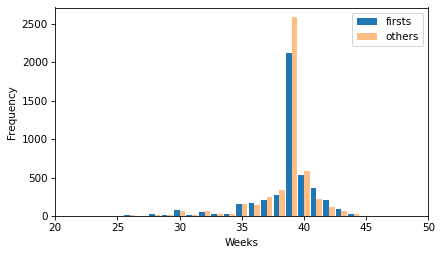

In [7]:
"""
Exploratory Data Analysis -- Visualization
Context: this snippet separates first pregnancies from others and compares their pregnancy-length distributions using side-by-side bar plots
Plain-English: it groups the data, builds frequency tables, and plots them together for comparison
Real-world: comparing distributions across groups is a common technique in statistical analysis
Reappears: yes; group comparison is central to answering the chapter’s main question
"""

# outcome is an integer for the outcome of the pregnancy. The code 1 indicates a live birth.
# we’ll focus on pregnancies that ended in live birth.

live = preg.query("outcome == 1")  # select only live birth records
print(live)

firsts = live.query("birthord == 1")  # select first pregnancies (first babies)
print(firsts)
others = live.query("birthord != 1")  # select all other pregnancies
print(others)


# we'll compare the distribution of pregnancy lengths for first babies and other

ftab_first = FreqTab.from_seq(firsts["prglngth"], name="firsts")  # frequency table for first babies
ftab_other = FreqTab.from_seq(others["prglngth"], name="others")  # frequency table for other babies


# ftab1.bars uses negative width which shifts bars to the left side (or bars extend left from the x-value)
# ftab2.bars uses positive width which shifts bars to the right side . 
# decorate(xlabel=xlabel) applies formatting to the same plot, creating side-by-side comparison on the same plot
# Both plots share same axes → direct comparison. 
# transparency (alpha=0.5) is applied to the second plot to make overlapping bars visible; by default alpha is 1.0 (no transparency)
# align="edge" is used for the bar is positioned so its edge starts at the x-value, not its center
# The xlim argument sets the limit of the x-axis to the range from 20 to 50 weeks
# there are not many values outside this range, and they are probably errors.

def two_bar_plots(ftab1, ftab2, width=0.45):  # define function to plot two frequency tables together
    ftab1.bar(align="edge", width=-width)  # plot first table shifted left
    ftab2.bar(align="edge", width=width, alpha=0.5)  # plot second table shifted right with transparency

two_bar_plots(ftab_first, ftab_other)  # display both distributions together
decorate(xlabel="Weeks", ylabel="Frequency", xlim=[20, 50])  # label axes for comparison



"""
Interpretation:
firsts and others split the dataset into two groups based on birth order.
ftab_first and ftab_other store frequency distributions of pregnancy length for each group.
The two bar plots are drawn on the same axes with opposite widths, so each week shows two adjacent bars.
If the shapes differ noticeably, it suggests a systematic difference between the groups.
Differences between the two plots indicate whether first babies tend to have different pregnancy lengths.

"""




print()

## interpretation:

There is no obvious difference in the shape of the distributions or in the outliers. It looks like more of the non-first babies are born during week 39, but there are more non-first babies in the dataset, so we should not compare the counts directly. Comparing the means of the distributions, it looks like first babies are a little bit later on average. But the difference is only 0.078 weeks, which is about 13 hours.

<!-- There are several possible causes of this apparent difference: -->

1. There might be an actual difference in average pregnancy length between first babies and others.

2. The apparent difference we see in this dataset might be the result of bias in the sampling process – that is, the selection of survey respondents.

3. The apparent difference might be the result of measurement error – for example, the self-reported pregnancy lengths might be more accurate for first babies or others.

4. The apparent difference might be the result of random variation in the sampling process.

In later chapters, we will consider these possible explanations more carefully, but for now we will take this result at face value: in this dataset, there is a small difference in pregnancy length between these groups.

## Snippet 6- Compare mean pregnancy length for first babies vs others
This snippet quantifies the difference between first pregnancies and others by computing counts and mean pregnancy lengths. It then converts the difference from weeks into hours to make the comparison more interpretable, following the chapter’s shift from visualization to numerical summary.

In [8]:
"""
Summary Statistics -- Group Comparison
Context: this snippet computes sample sizes and mean pregnancy lengths for two groups and measures their difference
Plain-English: it compares how long first pregnancies last on average versus others
Real-world: comparing group means is a standard statistical approach to quantify differences between populations
Reappears: yes; group comparisons are central to statistical inference later

""" 

# count non-missing pregnancy lengths in each group
first_count = firsts["prglngth"].count()
print(first_count)
others_count = others["prglngth"].count()
print(others_count)

first_mean = firsts["prglngth"].mean()  # compute mean pregnancy length for first babies
other_mean = others["prglngth"].mean()  # compute mean pregnancy length for other babies

# display both means for comparison
print(first_mean)
print(other_mean)  

diff = abs(first_mean - other_mean)  # compute absolute difference in weeks (first babies minus others)

print(diff, diff * 7 * 24) # display difference in weeks and convert it to hours (1 week = 7 days × 24 hours)


"""
Interpretation
The counts show how many valid observations are used for each group.
first_mean and other_mean represent average pregnancy length in weeks for first babies and others.
diff measures how much longer (or shorter) first pregnancies are on average.
diff * 7 * 24 converts the difference into hours for easier interpretation.
A small difference suggests that any observed effect may be minor in practical terms.

"""

print()

4413
4735
38.60095173351461
38.52291446673706
0.07803726677754952 13.11026081862832



## Snippet 7- Absolute, relative, and standardized effect sizes
This snippet introduces different ways to quantify an effect: absolute difference, relative difference (percentage), and standardized effect size. It highlights how the same difference can be interpreted differently depending on the scale and context, following the book’s discussion on measuring effect magnitude.

In [9]:
"""
Summary Statistics -- Effect Interpretation
Context: this snippet compares different ways to express the magnitude of a difference between two groups
Plain-English: it shows how to interpret the same difference in absolute, relative, and standardized terms
Real-world: reporting effect size in multiple ways is common in statistical analysis to improve interpretability
Reappears: yes; effect size interpretation is important in later statistical inference

"""


import numpy as np


# absolute effect
diff = abs(first_mean - other_mean) # absolute difference in weeks
print("absolute effect=", diff)


# relative effect (percentage difference)
print("relative effect=", diff / live["prglngth"].mean() * 100)  # expresses difference relative to overall mean pregnancy length


# standardized effect (naive approach using overall standard deviation)
print("standardized effect=", diff / live["prglngth"].std())  # expresses difference in units of standard deviation


"""
Interpretation:

Absolute effect (diff) shows the raw difference in weeks (~0.078 weeks).
Relative effect expresses this difference as a percentage of the average (~0.2%), indicating a very small change.
Standardized effect expresses the difference in terms of standard deviations, making it comparable across contexts.
However, using the combined standard deviation can underestimate the effect if the two groups differ.
This motivates the use of pooled or group-specific standard deviations (as in Cohen’s d)
"""

print()

absolute effect= 0.07803726677754952
relative effect= 0.20237586646738304
standardized effect= 0.028877623375210403



## Snippet 8- Compute Cohen’s effect size for pregnancy length difference
This snippet measures the magnitude of the difference between first pregnancies and others using Cohen’s d. It first computes the pooled standard deviation manually and uses it to calculate the effect size, then defines a reusable function for the same computation.

In [10]:
"""
Summary Statistics -- Effect Size
Context: this snippet computes Cohen’s d manually and via a function to quantify the standardized difference between two groups
Plain-English: it measures how large the difference is relative to variability in the data
Real-world: effect size is widely used to assess practical significance beyond simple mean differences
Reappears: yes; standardized comparisons are important in statistical inference

"""
# Effect size is a quantitative measure of the magnitude of the difference between two means
# Cohen's d is also a type of effect size between two means. It's standardize mean differences
# it is also the of number of standard deviation between two groups 


import numpy as np

group1 = firsts["prglngth"]   # assign pregnancy length data for firsts group
group2 = others["prglngth"]   # assign pregnancy length data for others groups

v1, v2 = group1.var(), group2.var()  # compute variances for each group
n1, n2 = group1.count(), group2.count()  # count non-missing observations in each group

pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)  # compute pooled variance (weighted average of variances)
pooled_std = np.sqrt(pooled_var)  # compute pooled standard deviation

diff = group1.mean() - group2.mean()  # compute difference in means
cohen_d = diff / pooled_std  # compute Cohen’s d manually
print("Manual Cohen's d=", cohen_d)  # display effect size



def cohen_effect_size(group1, group2):  # define function to compute Cohen’s d
    diff = group1.mean() - group2.mean()  # difference in group means

    v1, v2 = group1.var(), group2.var()  # variances of the two groups
    n1, n2 = group1.count(), group2.count()  # sample sizes

    pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)  # pooled variance

    return diff / np.sqrt(pooled_var)  # Cohen’s d = standardized mean difference

print (cohen_effect_size(firsts["prglngth"], others["prglngth"]))  # compute effect size using function

"""    
Interpretation:

diff measures the raw difference in mean pregnancy length.
pooled_std represents combined variability across both groups.
cohen_d expresses this difference in standard deviation units.
Values close to 0 indicate a very small practical difference between groups.
The function provides a reusable way to compute the same effect size.

"""


print()

Manual Cohen's d= 0.028879044654449834
0.028879044654449834



## Snippet 9- Load NSFG female respondent dataset for the exercise in this chapter
This snippet loads the NSFG female respondent file, which contains one row per respondent. It prepares additional data for analysis and highlights that although the dataset has many variables, only a subset will be used in practice.

In [11]:
"""
Data Loading
Context: this snippet downloads the female respondent dataset and loads it into a DataFrame for analysis
Plain-English: it fetches the respondent data and reads it into memory, then checks its size
Real-world: loading large survey datasets is common, but analysis typically focuses on a small subset of variables
Reappears: yes; loading and inspecting dataset structure is a standard first step in analysis

"""


download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")  # download data dictionary for respondent file
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")  # download compressed respondent dataset

from nsfg import read_fem_resp  # import function to read and clean respondent data

resp = read_fem_resp()  # load dataset into DataFrame named resp
print(resp)
print(resp.shape)  # display number of rows and columns



"""
Interpretation

The dataset contains one row per respondent and a large number of variables.
resp.shape confirms the size of the dataset, showing many columns relative to rows.
(7643, 3092)  # 7643 respondents (rows), 3092 variables (columns)
In practice, only a subset of variables is used for analysis to reduce complexity.
If shape is unexpected, it may indicate incomplete loading or file issues.

"""

print()

 Downloaded 2002FemResp.dct from URL
Downloaded 2002FemResp.dct
 Downloaded 2002FemResp.dat.gz from URL
Downloaded 2002FemResp.dat.gz
      caseid  rscrinf  rdormres  rostscrn  rscreenhisp  rscreenrace  age_a  \
0       2298        1         5         5            1          5.0     27   
1       5012        1         5         1            5          5.0     42   
2      11586        1         5         1            5          5.0     43   
3       6794        5         5         4            1          5.0     15   
4        616        1         5         4            1          5.0     20   
...      ...      ...       ...       ...          ...          ...    ...   
7638   11018        1         5         2            5          3.0     34   
7639    6075        5         5         3            5          3.0     17   
7640    5649        1         5         2            5          5.0     29   
7641     501        5         5         3            5          2.0     16   
7642   1

/Users/saadmanchowdhury/Desktop/All Github projects/01._eda_and_regression/drafts/nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
/Users/saadmanchowdhury/Desktop/All Github projects/01._eda_and_regression/drafts/nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
/Users/saadmanchowdhury/Desktop/All Github projects/01._eda_and_regression/drafts/nsfg.py:195: PerformanceWarning: DataFrame is highly fragmente

## Snippet 10- Frequency tables for income and parity (Exercises 2.1–2.2)
This snippet creates frequency tables for family income (totincr) and number of children (parity). It visualizes the income distribution and inspects the shape and extreme values of parity to identify potential data issues, following the chapter’s focus on empirical distributions and data quality.

totincr
1      299
2      301
3      266
4      421
5      445
6      559
7      583
8      606
9      607
10     468
11     647
12     658
13     623
14    1160
Name: totincr, dtype: int64
parity
0     3230
1     1519
2     1603
3      828
4      309
5       95
6       29
7       15
8        8
9        2
10       3
16       1
22       1
Name: parity, dtype: int64
parity
3     828
4     309
5      95
6      29
7      15
8       8
9       2
10      3
16      1
22      1
Name: parity, dtype: int64


'\nInterpretation\nThe income distribution shows how respondents are distributed across coded income levels.\nThe parity distribution is typically right-skewed, with most respondents having few children and fewer having many.\nlargest(ftab_parity) reveals extreme values in the right tail.\nVery large parity values (if present) may indicate data-entry errors or rare cases that need verification.\nAlways compare suspicious values with the codebook before deciding to clean them.\n\n'

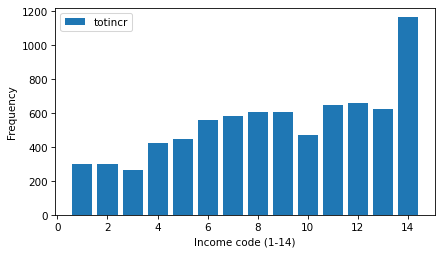

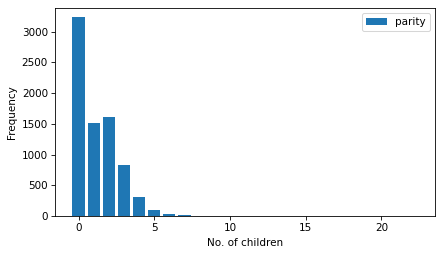

In [12]:
"""
Exploratory Data Analysis -- Frequency Tables
Context: this snippet builds and inspects frequency tables for income and parity, including visualization and tail inspection
Plain-English: it counts values, plots income distribution, and checks parity for shape and extreme values
Real-world: frequency tables help understand categorical/ordinal variables and detect anomalies
Reappears: yes; inspecting distributions and tails is a standard exploratory step

"""

"""Exercise 2.1: total income (coded 1-14)"""


#  totincr, which records the total income for the respondent’s family

import matplotlib.pyplot as plt  # import pyplot so we can create a new figure for each plot
ftab_income = FreqTab.from_seq(resp["totincr"], name="totincr")  # build frequency table for income codes
print(ftab_income)
plt.figure()
ftab_income.bar()  # plot income distribution
decorate(xlabel="Income code (1-14)", ylabel="Frequency")  # label axes



"""Exercise 2.2: parity (number of children)"""

# parity records the number of children each respondent has borne
ftab_parity = FreqTab.from_seq(resp["parity"], name="parity")  # build frequency table for parity
print(ftab_parity)  # display counts to inspect overall shape
plt.figure()
ftab_parity.bar()
decorate(xlabel="No. of children", ylabel="Frequency")  # label axes

def largest(ftab, n=10):  # define function that returns the last n entries from a frequency table
    return ftab[-n:]  # slice from the end to inspect the largest values and their frequencies

print(largest(ftab_parity))  # inspect largest parity values (right tail)


"""
Interpretation
The income distribution shows how respondents are distributed across coded income levels.
The parity distribution is typically right-skewed, with most respondents having few children and fewer having many.
largest(ftab_parity) reveals extreme values in the right tail.
Very large parity values (if present) may indicate data-entry errors or rare cases that need verification.
Always compare suspicious values with the codebook before deciding to clean them.

"""

## Snippet 11- Income vs parity and effect size (Exercise 2.3)
This snippet investigates whether higher income respondents have different numbers of children. It filters high-income respondents, compares parity distributions and means, and computes effect sizes using the same structure as earlier, keeping the workflow consistent and directly comparable.

parity
0    515
1    229
2    267
3    123
4     19
5      5
7      1
8      1
Name: high_income_parity, dtype: int64
1160
6483
1.0758620689655172
1.2495758136665125
0.17371374470099532 0.17371374470099532
absolute effect= 0.17371374470099532
relative effect= 14.201456313506334
standardized effect= 0.12499891827375545
-0.12511855314660367


'\nInterpretation\nThe bar plot shows how parity is distributed among high-income respondents.\nComparing means indicates whether high-income respondents tend to have more or fewer children.\nAbsolute and relative effects quantify the size of the difference.\nThe standardized effect (Cohen’s d) allows comparison with the earlier pregnancy-length result.\nTypically, this effect is small, similar to the earlier comparison, suggesting limited practical difference.\nHowever, this does not imply causation; factors like age, education, and delayed childbearing may explain the observed pattern.\n\n'

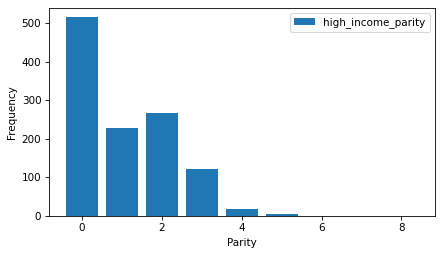

In [13]:
"""
Exploratory Data Analysis -- Group Comparison
Context: this snippet compares parity between high-income respondents and others, then quantifies the difference using absolute, relative, and standardized effects
Plain-English: it checks whether richer respondents have more or fewer children and measures how big the difference is
Real-world: comparing outcomes across socioeconomic groups is common, but interpretation requires caution
Reappears: yes; effect size comparison is used to judge practical significance

"""
# totincr, which records the total income for the respondent’s family
# parity column, which records the number of children each respondent has borne
# lowest income respondents are in income level 3


# select high-income respondents (income level 14)
high_income = resp.query("totincr == 14")  # highest income group
others_income = resp.query("totincr != 14")  # all other respondents


# frequency table for parity (number of children) for high-income group
ftab_high = FreqTab.from_seq(high_income["parity"], name="high_income_parity")
print(ftab_high)
ftab_high.bar()      #Plot parity for just the high income respondents.
decorate(xlabel="Parity", ylabel="Frequency")


# counts
high_count = high_income["parity"].count()
print(high_count)
others_count = others_income["parity"].count()
print(others_count)

# means
high_mean = high_income["parity"].mean()
print(high_mean)
other_mean = others_income["parity"].mean()
print(other_mean)

# Comparing the mean parity for high income respondents and others 
# absolute effect
diff = abs(high_mean - other_mean)
print(diff, diff * 1)  # parity is already a count, so no unit conversion needed

print("absolute effect=", diff)

# relative effect
print("relative effect=", diff / resp["parity"].mean() * 100)

# standardized effect (naive)
print("standardized effect=", diff / resp["parity"].std())


# Compute Cohen’s effect size for this difference
import numpy as np

group1 = high_income["parity"]
group2 = others_income["parity"]

def cohen_effect_size(group1, group2):
    diff = group1.mean() - group2.mean()

    v1, v2 = group1.var(), group2.var()
    n1, n2 = group1.count(), group2.count()

    pooled_var = (n1 * v1 + n2 * v2) / (n1 + n2)

    return diff / np.sqrt(pooled_var)

print(cohen_effect_size(high_income["parity"], others_income["parity"]))


"""
Interpretation
The bar plot shows how parity is distributed among high-income respondents.
Comparing means indicates whether high-income respondents tend to have more or fewer children.
Absolute and relative effects quantify the size of the difference.
The standardized effect (Cohen’s d) allows comparison with the earlier pregnancy-length result.
Typically, this effect is small, similar to the earlier comparison, suggesting limited practical difference.
However, this does not imply causation; factors like age, education, and delayed childbearing may explain the observed pattern.

"""

# Cohen’s d = -0.125 indicates a small effect; high-income respondents have slightly lower parity, but this likely reflects delayed childbearing rather than a causal income effect